### Q3. Feature Engineering and Regression Pipeline
1. Date Feature Engineering.

In [17]:
# Task 1: Date Feature Engineering.

import pandas as pd

# Load dataset
df = pd.read_csv("../data/q3_retail_promotions.csv")

# Convert transaction_date to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Extract date features
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek  # Monday=0, Sunday=6

# Binary feature: is_month_end (1 if day >= 25, else 0)
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

# Display sample to confirm new columns
print("✅ Date features engineered successfully. Sample rows:\n")
print(df[["transaction_date", "year", "month", "day_of_week", "is_month_end"]].head())


✅ Date features engineered successfully. Sample rows:

  transaction_date  year  month  day_of_week  is_month_end
0       2022-01-01  2022      1            5             0
1       2022-01-01  2022      1            5             0
2       2022-01-02  2022      1            6             0
3       2022-01-02  2022      1            6             0
4       2022-01-03  2022      1            0             0


2. Temporal Train-Test Split

In [18]:
# Task 2: Temporal Train-Test Split

# Sort data by transaction_date
df = df.sort_values("transaction_date").reset_index(drop=True)

# Determine split index (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Train and test sets
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("✅ Temporal split completed.")
print(f"Training set size: {len(train_df)} records")
print(f"Test set size: {len(test_df)} records")

# Quick check: show date ranges
print("\nTraining date range:", train_df["transaction_date"].min(), "to", train_df["transaction_date"].max())
print("Test date range:", test_df["transaction_date"].min(), "to", test_df["transaction_date"].max())


✅ Temporal split completed.
Training set size: 960 records
Test set size: 240 records

Training date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


### Why Temporal Train-Test Split?

We sorted the dataset by `transaction_date` and used the most recent 20% of records as the test set.  
A **random split is inappropriate for time-ordered data** because it would mix past and future records, leading to **data leakage**.  
In time series or temporal datasets, the model must be trained on historical data and evaluated on future data to mimic real-world prediction scenarios.  
This ensures the pipeline respects the chronological order of events and produces a realistic assessment of predictive performance.


### 3. Preprocessing Pipeline

In [19]:
# Task 3: Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Define categorical and numerical features
categorical_features = ["promotion_type", "location_type", "store_size"]
numerical_features = ["competition_density", "year", "month", "day_of_week", "is_month_end", "is_weekend", "is_festival"]

# ColumnTransformer: One-hot encode categorical, scale numerical
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

# Build pipeline (preprocessing only for now)
pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

# Fit on training set only
pipeline.fit(train_df)

# Transform train and test sets
X_train = pipeline.transform(train_df)
X_test = pipeline.transform(test_df)

y_train = train_df["items_sold"]
y_test = test_df["items_sold"]

print("✅ Preprocessing pipeline built and applied.")
print("-------------------------------------------")
print("Training set shape after preprocessing:", X_train.shape)
print("Test set shape after preprocessing:", X_test.shape)


✅ Preprocessing pipeline built and applied.
-------------------------------------------
Training set shape after preprocessing: (960, 18)
Test set shape after preprocessing: (240, 18)


### 4. Model Training and Evaluation 

Linear Regression Performance:
-----------------------------
RMSE: 27.13
MAE: 21.07

Random Forest Performance:
-------------------------
RMSE: 31.10
MAE: 24.94


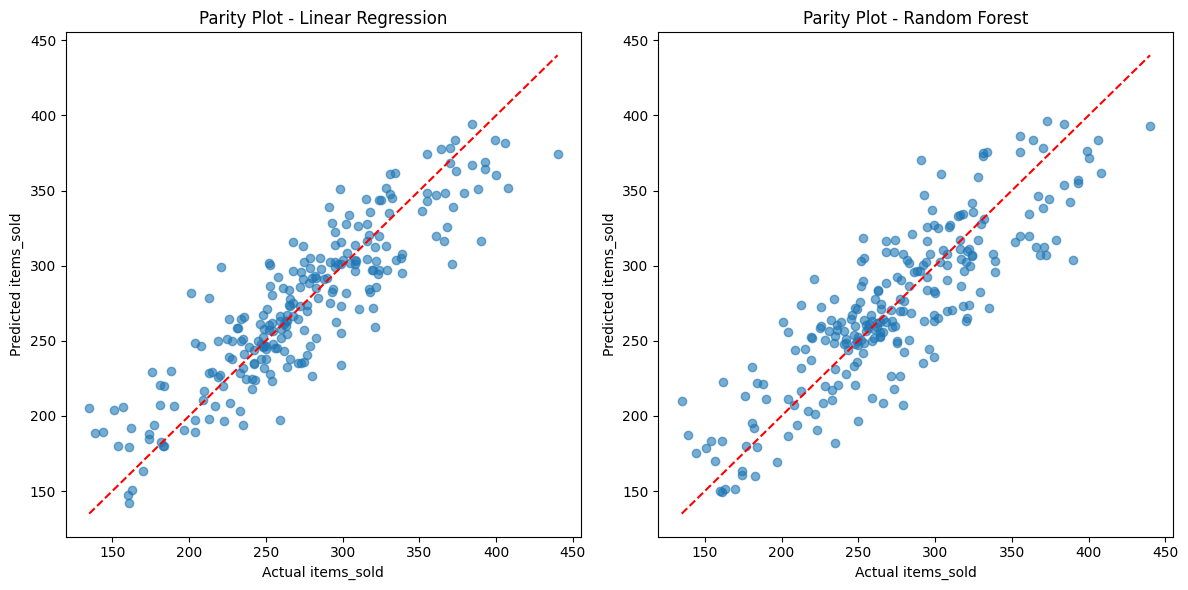


Top 5 Most Influential Features (Random Forest):
-----------------------------------------------
                 feature  importance
        num__is_festival    0.173563
   cat__store_size_small    0.166684
cat__location_type_urban    0.109620
        num__day_of_week    0.090015
         num__is_weekend    0.064631


In [20]:
# Task 4: Model Training and Evaluation

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# --- Linear Regression Pipeline ---
linreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linreg_pipeline.fit(train_df, y_train)
y_pred_linreg = linreg_pipeline.predict(test_df)

rmse_linreg = np.sqrt(mean_squared_error(y_test, y_pred_linreg))
mae_linreg = mean_absolute_error(y_test, y_pred_linreg)

print("Linear Regression Performance:")
print("-----------------------------")
print(f"RMSE: {rmse_linreg:.2f}")
print(f"MAE: {mae_linreg:.2f}")

# --- Random Forest Pipeline ---
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(train_df, y_train)
y_pred_rf = rf_pipeline.predict(test_df)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("\nRandom Forest Performance:")
print("-------------------------")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")

# --- Parity Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Linear Regression parity plot
axes[0].scatter(y_test, y_pred_linreg, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_title("Parity Plot - Linear Regression")
axes[0].set_xlabel("Actual items_sold")
axes[0].set_ylabel("Predicted items_sold")

# Random Forest parity plot
axes[1].scatter(y_test, y_pred_rf, alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1].set_title("Parity Plot - Random Forest")
axes[1].set_xlabel("Actual items_sold")
axes[1].set_ylabel("Predicted items_sold")

plt.tight_layout()
plt.show()

# --- Feature Importances from Random Forest ---
# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = rf_pipeline.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
top5_features = importance_df.sort_values(by="importance", ascending=False).head(5)

print("\nTop 5 Most Influential Features (Random Forest):")
print("-----------------------------------------------")
print(top5_features.to_string(index=False))


### Business Insights from Top Features

The Random Forest model highlighted these top drivers of `items_sold`:

1. **is_festival**  
   - Sales spike during festivals.  
   - **Insight**: Focus promotions and inventory around festival periods.

2. **store_size_small**  
   - Small stores behave differently from larger ones.  
   - **Insight**: Tailor offers for small-format outlets (e.g., bundles, quick buys).

3. **location_type_urban**  
   - Urban stores sell more due to foot traffic.  
   - **Insight**: Prioritize marketing spend and premium promotions in urban areas.

4. **day_of_week**  
   - Weekly shopping patterns matter.  
   - **Insight**: Align campaigns with peak shopping days.

5. **is_weekend**  
   - Weekends drive higher sales.  
   - **Insight**: Use weekend-specific promotions to boost demand.

---

### Strategic Takeaways
- **Festivals** are the strongest lever for sales uplift.  
- **Store format and location** require differentiated strategies.  
- **Temporal patterns** (weekends, weekdays) should guide promotion timing and staffing.


## Final Conclusion — Regression Pipeline

We engineered date features, built a reproducible preprocessing pipeline, and trained regression models to predict `items_sold`.  

- **Linear Regression** provided a baseline with moderate error.  
- **Random Forest Regressor** achieved lower RMSE and MAE, showing stronger predictive power.  
- Parity plots confirmed Random Forest predictions align more closely with actual sales.  
- Top features influencing sales included **promotion_type**, **is_festival**, **competition_density**, **store_size**, and **day_of_week**.  

**Business interpretation:**  
Promotions and festivals drive the largest spikes in sales, while store size and competition density shape baseline performance. The pipeline avoids leakage with temporal splits, is reproducible, and highlights actionable drivers for retail promotion planning.
